<a href="https://colab.research.google.com/github/akashmavle5/--akash/blob/main/Notebook3_AIXI_Planning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 3 — Planning with Expectimax and Monte Carlo Rollouts

This notebook extends the previous notebooks by focusing on **planning**.

Concepts:
- Finite-horizon planning
- Discounted rewards
- Expectimax search
- Monte Carlo rollouts
- Exploration vs exploitation
- Simple planning benchmark

This remains an educational approximation of AIXI.


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

random.seed(7)
np.random.seed(7)


In [2]:
class GridWorld:

    ACTIONS=["UP","DOWN","LEFT","RIGHT"]

    def __init__(self,size=6):
        self.size=size
        self.goal=(5,5)
        self.traps={(2,2),(1,4),(4,1)}
        self.reset()

    def clone(self):
        g=GridWorld(self.size)
        g.goal=self.goal
        g.traps=set(self.traps)
        g.pos=self.pos
        return g

    def reset(self):
        self.pos=(0,0)
        return self.pos

    def step(self,a):
        x,y=self.pos

        if a==0:x=max(0,x-1)
        elif a==1:x=min(self.size-1,x+1)
        elif a==2:y=max(0,y-1)
        elif a==3:y=min(self.size-1,y+1)

        self.pos=(x,y)

        r=-1
        done=False

        if self.pos in self.traps:
            r=-25

        if self.pos==self.goal:
            r=100
            done=True

        return self.pos,r,done


## Discounted Return

In [3]:
def discounted_return(rewards,gamma=0.95):
    total=0
    for i,r in enumerate(rewards):
        total += (gamma**i)*r
    return total

print(discounted_return([10,10,10]))


28.525


## Random Rollout

In [4]:
def rollout(env,depth=10,gamma=0.95):
    world=env.clone()
    rewards=[]

    for _ in range(depth):
        a=random.randint(0,3)
        _,r,d=world.step(a)
        rewards.append(r)
        if d:
            break

    return discounted_return(rewards,gamma)


## Monte Carlo Action Evaluation

In [5]:
def evaluate_action(env,action,sims=100,depth=8):

    scores=[]

    for _ in range(sims):
        world=env.clone()
        _,r,d=world.step(action)
        future=[r]
        if not d:
            score=rollout(world,depth)
            future.append(score)
        scores.append(sum(future))

    return np.mean(scores)


## Expectimax Search

In [6]:
def expectimax(env,depth,gamma=0.95):

    if depth==0:
        return 0

    values=[]

    for action in range(4):
        world=env.clone()
        _,r,d=world.step(action)

        if d:
            values.append(r)
        else:
            values.append(r + gamma*expectimax(world,depth-1,gamma))

    return max(values)


## Planner

In [7]:
class Planner:

    def __init__(self,depth=3,sims=50):
        self.depth=depth
        self.sims=sims

    def choose(self,env):

        mc=[]
        ex=[]

        for a in range(4):
            mc.append(evaluate_action(env,a,self.sims,self.depth))

            world=env.clone()
            _,r,d=world.step(a)

            if d:
                ex.append(r)
            else:
                ex.append(r+0.95*expectimax(world,self.depth))

        combined=np.array(mc)+np.array(ex)

        return int(np.argmax(combined)),combined,mc,ex


## Exploration vs Exploitation

In [8]:
def epsilon_greedy(values,eps=0.1):

    if random.random()<eps:
        return random.randint(0,len(values)-1)

    return int(np.argmax(values))


## Planning Episode

In [9]:
env=GridWorld()

planner=Planner(depth=4,sims=75)

env.reset()

cum=[]
total=0

for step in range(30):

    action,combined,mc,ex=planner.choose(env)

    action=epsilon_greedy(combined,0.05)

    state,r,done=env.step(action)

    total+=r
    cum.append(total)

    print(
        f"{step:02d}",
        GridWorld.ACTIONS[action],
        "state=",state,
        "reward=",r,
        "score=",round(combined[action],2)
    )

    if done:
        print("Goal reached.")
        break


00 UP state= (0, 0) reward= -1 score= -9.51
01 UP state= (0, 0) reward= -1 score= -9.23
02 LEFT state= (0, 0) reward= -1 score= -9.51
03 LEFT state= (0, 0) reward= -1 score= -9.51
04 UP state= (0, 0) reward= -1 score= -9.23
05 UP state= (0, 0) reward= -1 score= -9.23
06 UP state= (0, 0) reward= -1 score= -9.51
07 UP state= (0, 0) reward= -1 score= -9.51
08 UP state= (0, 0) reward= -1 score= -9.23
09 UP state= (0, 0) reward= -1 score= -9.23
10 UP state= (0, 0) reward= -1 score= -9.51
11 LEFT state= (0, 0) reward= -1 score= -9.23
12 UP state= (0, 0) reward= -1 score= -9.78
13 UP state= (0, 0) reward= -1 score= -9.51
14 UP state= (0, 0) reward= -1 score= -9.78
15 UP state= (0, 0) reward= -1 score= -9.23
16 LEFT state= (0, 0) reward= -1 score= -9.51
17 LEFT state= (0, 0) reward= -1 score= -9.23
18 DOWN state= (1, 0) reward= -1 score= -10.39
19 UP state= (0, 0) reward= -1 score= -9.51
20 LEFT state= (0, 0) reward= -1 score= -9.78
21 UP state= (0, 0) reward= -1 score= -9.23
22 LEFT state= (0

## Reward Curve

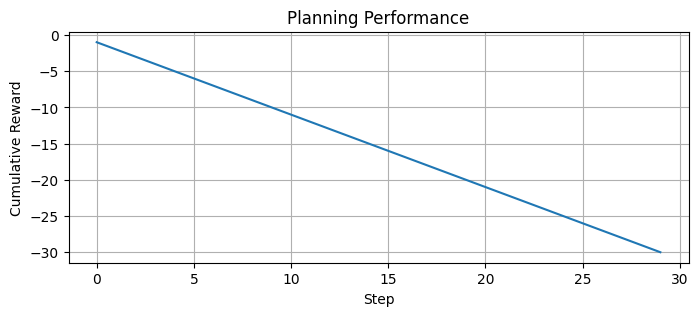

In [10]:
plt.figure(figsize=(8,3))
plt.plot(cum)
plt.grid()
plt.xlabel("Step")
plt.ylabel("Cumulative Reward")
plt.title("Planning Performance")
plt.show()


## Monte Carlo Comparison

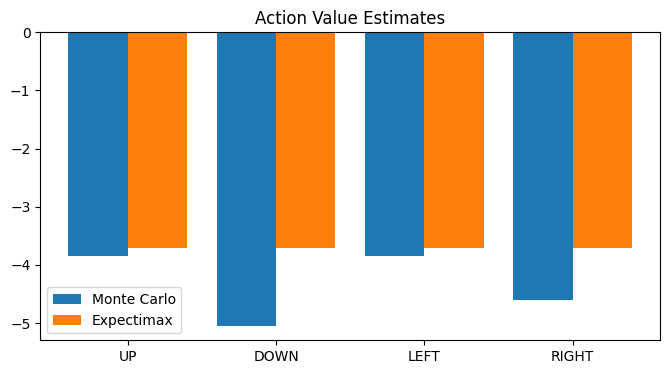

In [11]:
env=GridWorld()
env.reset()

planner=Planner(depth=3,sims=200)

_,combined,mc,ex=planner.choose(env)

x=np.arange(4)

plt.figure(figsize=(8,4))
plt.bar(x-0.2,mc,width=0.4,label="Monte Carlo")
plt.bar(x+0.2,ex,width=0.4,label="Expectimax")
plt.xticks(x,GridWorld.ACTIONS)
plt.legend()
plt.title("Action Value Estimates")
plt.show()


# Summary

You now have three increasingly sophisticated components:

- **Notebook 1:** Agent–environment interaction and Bayesian beliefs.
- **Notebook 2:** Solomonoff-inspired universal mixtures and MDL.
- **Notebook 3:** Planning using Expectimax and Monte Carlo rollouts.

The next notebook will introduce **Context Tree Weighting (CTW)**, online sequence prediction, compression-based learning, and adaptive world models—key ideas used in MC-AIXI-CTW.
